# **📌Problem Statement**

The objective of this project is to build a machine learning classification model that predicts student placement outcomes based on academic performance, technical skills, and experiential factors. The model aims to identify key attributes influencing placement decisions and assist institutions in understanding employability trends.

# **🎯Target Feature**

**Placement** – This is the target variable that indicates whether a student is successfully placed or not. It is a binary categorical feature with values Yes (placed) and No (not placed).

### **📂Loading and Understanding Data**

In [1]:
# importing required libraries
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Loading the dataset
df=pd.read_csv("/content/college_student_placement_dataset.csv")

In [4]:
# Read the data
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [5]:
# check the data shape
df.shape

(10000, 10)

In [6]:
# Check the data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [7]:
# Checking the datatypes of all the columns
df.dtypes

,0
College_ID,object
IQ,int64
Prev_Sem_Result,float64
CGPA,float64
Academic_Performance,int64
Internship_Experience,object
Extra_Curricular_Score,int64
Communication_Skills,int64
Projects_Completed,int64
Placement,object


In [8]:
df.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


## **Observations :**

* The dataset contains 10,000 student records with 9 input features and 1 target variable (Placement).

* The target variable Placement is categorical with values Yes / No, making this a binary classification problem.

* The dataset contains both numerical and categorical features, and there are no missing values.

*   **Categorical Features:** Internship_Experience,Placement

*   **Discrete Numerical Features:** Projects_Completed

*   **Continuous Numerical Features:**
IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills

* Statistical analysis shows that most students have moderate to high CGPA, average communication skills, and have completed around 2–3 projects.

# **🧹Data Cleaning**

In [9]:
#Dropping the unwanted column College_ID
df=df.drop(columns="College_ID")

In [10]:
df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No


In [10]:
df.shape

(10000, 9)

In [11]:
#Identifying percentage of null values
df.isnull().sum()/len(df)*100

,0
IQ,0.0
Prev_Sem_Result,0.0
CGPA,0.0
Academic_Performance,0.0
Internship_Experience,0.0
Extra_Curricular_Score,0.0
Communication_Skills,0.0
Projects_Completed,0.0
Placement,0.0


In [12]:
#Checking the duplicate values
df.duplicated().sum()

np.int64(0)

In [13]:
#Checking nunique for all columns
for i in df.columns:
  print(i,df[i].nunique())

IQ 104
Prev_Sem_Result 501
CGPA 590
Academic_Performance 10
Internship_Experience 2
Extra_Curricular_Score 11
Communication_Skills 10
Projects_Completed 6
Placement 2


In [14]:
# Feature Encoding
# Convert target column 'Placement' to numerical using Label Encoding (Yes/No → 1/0)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Placement'] = le.fit_transform(df['Placement'])

df['Internship_Experience'] = le.fit_transform(df['Internship_Experience'])

In [15]:
# Data Unbalance
df['Placement'].value_counts()

,count
Placement,
0,8341
1,1659


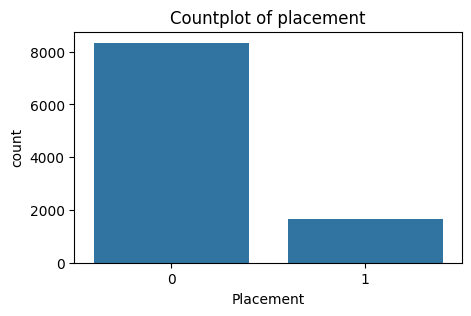

In [16]:
plt.figure(figsize=(5,3))
sns.countplot(x='Placement',data=df)
plt.title('Countplot of placement')
plt.show()

## **Observations :**

* After removing the unnecessary column, the dataset contains 10,000 records and 9 features, including the target variable.

* A check for missing values showed 0% null values in all columns, indicating that the dataset is complete and no missing value handling was required.

* The dataset was also checked for duplicate records, and no duplicate entries were found, meaning each row represents a unique student.

* Categorical variables such as Placement and Internship_Experience were converted into numerical values using Label Encoding (Yes → 1, No → 0) so that machine learning algorithms can process the data.

* Specifically, 8,341 students are not placed while 1,659 students are placed, indicating that the majority class is "not placed".

* The count plot visualization confirms this class imbalance, where the number of non-placed students is much higher than the number of placed students.


## **Distribution and Outlier Analysis of Numerical Features**

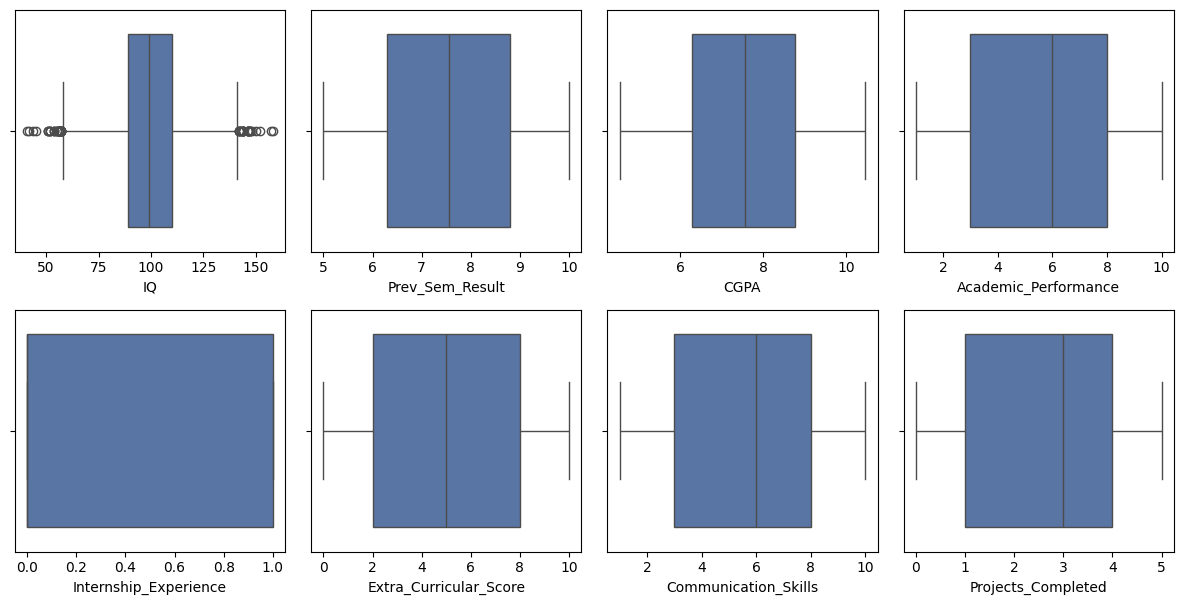

In [22]:
# Detecting Outliers using Boxplot

num_cols = df.select_dtypes(include=['number']).drop(columns=['Placement'])

n_cols = 4 # plots per row
n_rows = math.ceil(len(num_cols) / n_cols)
plt.figure(figsize=(12, 3 * n_rows))

for i, col in enumerate(num_cols, 1):
   plt.subplot(n_rows, n_cols, i)
   sns.boxplot(x=df[col], color="#4C72B0")

plt.tight_layout()
plt.show()



## **Observations :**

* IQ feature shows a few outliers, indicating some students have unusually low or high IQ compared to the majority.

* Apart from IQ, most features do not show significant outliers and have relatively balanced distributions.

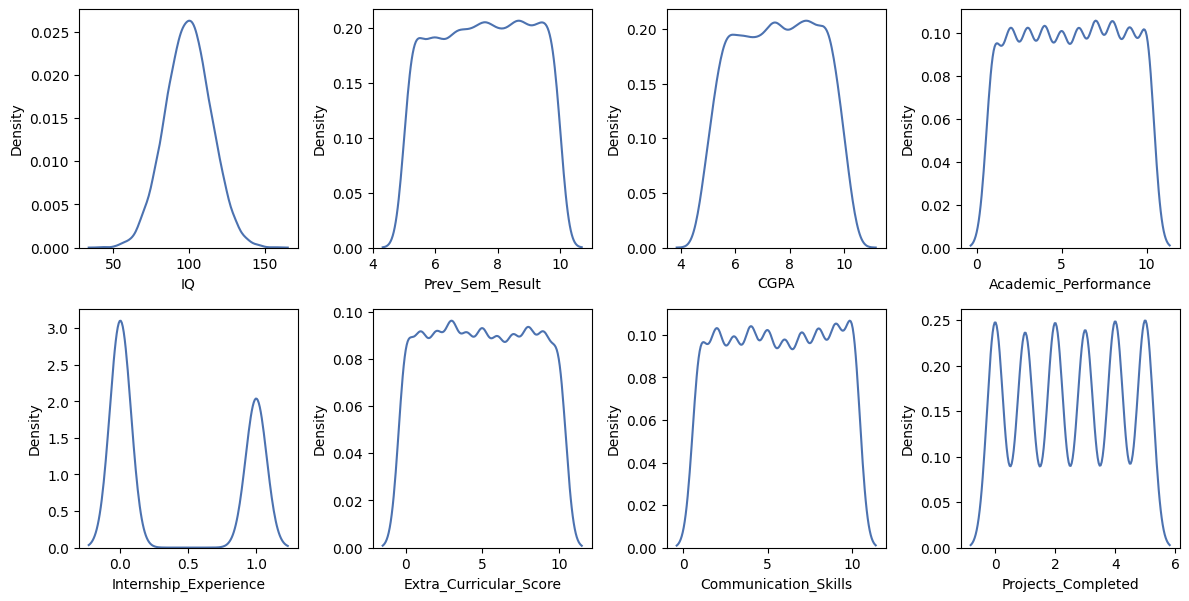

In [24]:
# Observing Distribution using KDE plot
plt.figure(figsize=(12, 3 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(x=df[col], color="#4C72B0")

plt.tight_layout()
plt.show()

## **Observations :**


The distribution plots show how numerical features are distributed across the dataset.

Overall, the features show fairly smooth distributions without extreme skewness, which is beneficial for machine learning models.

In [25]:
df.corr()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
IQ,1.000000,-0.002640,-0.002859,-0.006827,-0.000247,-0.003458,-0.010896,0.014538,0.285914
Prev_Sem_Result,-0.002640,1.000000,0.980768,-0.005765,-0.013347,0.009326,-0.017269,0.018434,0.317896
CGPA,-0.002859,0.980768,1.000000,-0.002958,-0.012562,0.011441,-0.018242,0.020872,0.321607
Academic_Performance,-0.006827,-0.005765,-0.002958,1.000000,0.025903,0.011774,-0.019733,-0.013148,-0.014920
Internship_Experience,-0.000247,-0.013347,-0.012562,0.025903,1.000000,0.002093,-0.020437,-0.010260,-0.005841
Extra_Curricular_Score,-0.003458,0.009326,0.011441,0.011774,0.002093,1.000000,0.003769,0.008122,-0.004740
Communication_Skills,-0.010896,-0.017269,-0.018242,-0.019733,-0.020437,0.003769,1.000000,-0.004486,0.323155
Projects_Completed,0.014538,0.018434,0.020872,-0.013148,-0.010260,0.008122,-0.004486,1.000000,0.217499
Placement,0.285914,0.317896,0.321607,-0.014920,-0.005841,-0.004740,0.323155,0.217499,1.000000


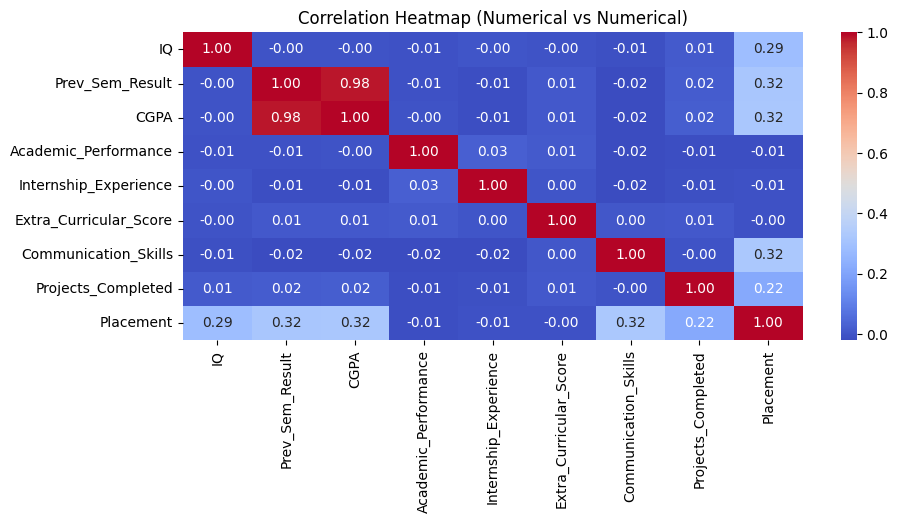

In [26]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numerical vs Numerical)")
plt.show()

## **Observations :**

* Previous Semester Result and CGPA have a very strong positive correlation (~0.98), meaning both represent similar academic performance.

* Placement shows moderate positive correlation with Communication Skills, CGPA, and Previous Semester Result (~0.32),IQ (~0.29),Projects Completed (~0.22)  indicating these features may influence placement.

* Most other features show very weak correlation, meaning they have limited direct impact on placement.

* The heatmap helps identify important predictive features and detect multicollinearity between variables.

# **📈Predictive Modeling and Analysis**

# **Step1 : Selecting Target Variable**

In [27]:
#Selecting the target variable and predictors
y=df["Placement"]
X=df.drop(columns="Placement")

In [28]:
print(X.shape)
print(y.shape)

(10000, 8)
(10000,)


# **Step2 : Splitting the data into Train and Test data**

In [29]:
#Splitting data into X_train,X_test,y_train and y_test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=24)

In [30]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 8)
(2000, 8)
(8000,)
(2000,)


In [31]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 6604 to 899
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IQ                      8000 non-null   int64  
 1   Prev_Sem_Result         8000 non-null   float64
 2   CGPA                    8000 non-null   float64
 3   Academic_Performance    8000 non-null   int64  
 4   Internship_Experience   8000 non-null   int64  
 5   Extra_Curricular_Score  8000 non-null   int64  
 6   Communication_Skills    8000 non-null   int64  
 7   Projects_Completed      8000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 562.5 KB


# **Step3 : Data Preprocessing**

In [32]:
#Lets use columntransformer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
transformer=ColumnTransformer(transformers=[("t1",StandardScaler(),[0,1,2,3,5,6,7])],remainder="passthrough")

#fit_transform on train data
X_train_trans=transformer.fit_transform(X_train)

#transform on test data
X_test_trans=transformer.transform(X_test)

In [33]:
# Let us convert X_train_trans to DataFrame
X_train_trans=pd.DataFrame(X_train_trans,columns=X_train.columns)

# Let us convert X_test_trans to DataFrame
X_test_trans=pd.DataFrame(X_test_trans,columns=X_test.columns)

In [34]:
X_train_trans.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
0,-0.024792,-1.592960,-1.898928,-1.243852,1.280106,0.833849,-0.302343,1.0
1,1.298336,-1.620626,-1.599426,0.848781,1.598481,-1.583104,-0.886158,0.0
2,-0.620200,0.641040,0.796588,-0.546308,-0.630144,-1.237825,0.281472,0.0
3,1.430649,-1.205641,-1.456482,0.500008,-0.948519,-0.547267,1.449101,1.0
4,0.835241,-1.475381,-1.790018,1.546325,0.643356,1.179128,-0.886158,1.0


In [35]:
X_test_trans.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
0,0.305990,-0.175097,-0.204020,-0.546308,0.324981,-1.237825,-0.302343,0.0
1,0.107521,-1.710539,-1.755984,0.151236,0.961731,-0.547267,-0.886158,1.0
2,1.166024,1.567838,1.204999,-0.895080,-0.311769,1.524407,1.449101,0.0
3,-0.950982,1.194352,0.953146,1.546325,-1.585269,-0.201988,0.281472,0.0
4,-0.487887,1.505591,1.347943,-0.546308,0.961731,0.833849,-1.469973,1.0


In [36]:
X_train_trans.shape

(8000, 8)

In [37]:
X_test_trans.shape

(2000, 8)

# **Model Building**

## **📍KNN CLASSIFIER**

In [38]:
#Importing KNN classifier and pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

# Create a pipeline:
knn = make_pipeline(transformer,KNeighborsClassifier(n_neighbors=5))

#Fitting kNN model
print(knn.fit(X_train, y_train))
 #print(knn)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', StandardScaler(),
                                                  [0, 1, 2, 3, 5, 6, 7])])),
                ('kneighborsclassifier', KNeighborsClassifier())])


Accuracy Score of train data : 0.967375

Accuracy Score of test data : 0.955

Confusion Matrix : 
 [[1648   36]
 [  54  262]]

Classfication Report: 
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      1684
           1       0.88      0.83      0.85       316

    accuracy                           0.95      2000
   macro avg       0.92      0.90      0.91      2000
weighted avg       0.95      0.95      0.95      2000


Confusion Matrix Display: 


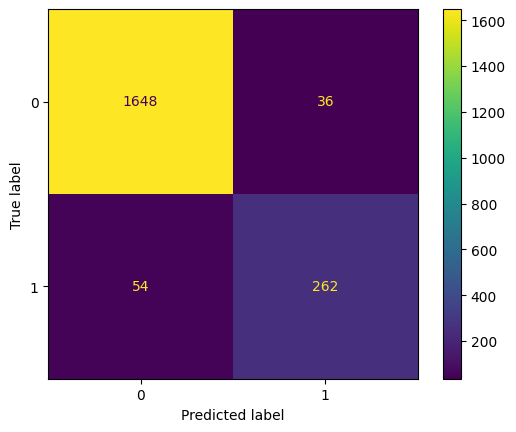

In [39]:
# Importing evaluation metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay,roc_auc_score

# Evaluating overall model accuracy
y_pred = knn.predict(X_train)
print("Accuracy Score of train data :",accuracy_score(y_train,y_pred))
print()

y_pred = knn.predict(X_test)
print("Accuracy Score of test data :",accuracy_score(y_test,y_pred))
print()

# Displaying confusion matrix values
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred))
print()

# Displaying detailed classification report
print("Classfication Report: \n",classification_report(y_test,y_pred))
print()

#Plot confusion matrix for visual understanding
print("Confusion Matrix Display: \n",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

AUC Score: 0.9766595132144683


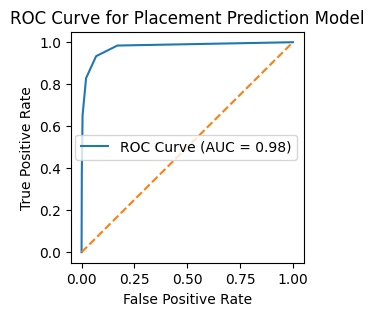

In [40]:
# AUC_ROC

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probability predictions
y_prob = knn.predict_proba(X_test)[:,1]

# AUC score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot
plt.figure(figsize=(3,3))
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % auc_score)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Placement Prediction Model")
plt.legend()
plt.show()

# **Observations :**

**Model-wise Performance Observations**

The model achieved 95.5% accuracy, reflecting strong predictive performance.

In this case, the model correctly predicted 1648 students as not placed and 262 students as placed. However, it incorrectly predicted 36 students as placed and 54 students as not placed.

**Class-wise Performance Observations**

Not Placed (No): Precision 0.97 and Recall 0.98, indicating excellent identification with minimal errors.

Placed (Yes): Precision 0.88 and Recall 0.83, showing reliable predictions with some missed placed students.

## **🌳DECISIONTREE CLASSIFIER**

#### **Hyperparameter Tuning**

In [41]:
#Let us implement hyperparameter tuning using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

tuned_parameters = [{
    "max_depth": list(range(1, 4))
}]

clf_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(),
    param_distributions=tuned_parameters,
    scoring="accuracy",
    cv=5,
    return_train_score=True,
)

clf_dt.fit(X_train_trans, y_train)

# Printing accuracy scores of both train and test data
print(clf_dt.best_params_)
print(clf_dt.score(X_train_trans, y_train))
print(clf_dt.score(X_test_trans, y_test))

{'max_depth': 3}
0.961375
0.9515


In [42]:
#Importing DecisionTree classifier
from sklearn.tree import DecisionTreeClassifier

#Creating pipeline and fitting the model
dt=make_pipeline(transformer,DecisionTreeClassifier(max_depth=3))
print(dt.fit(X_train,y_train))


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', StandardScaler(),
                                                  [0, 1, 2, 3, 5, 6, 7])])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=3))])


Accuracy Score of train data : 0.961375

Accuracy Score of test data : 0.9515

Confusion Matrix : 
 [[1610   74]
 [  23  293]]

Classfication Report: 
               precision    recall  f1-score   support

           0       0.99      0.96      0.97      1684
           1       0.80      0.93      0.86       316

    accuracy                           0.95      2000
   macro avg       0.89      0.94      0.91      2000
weighted avg       0.96      0.95      0.95      2000


Confusion Matrix Display: 


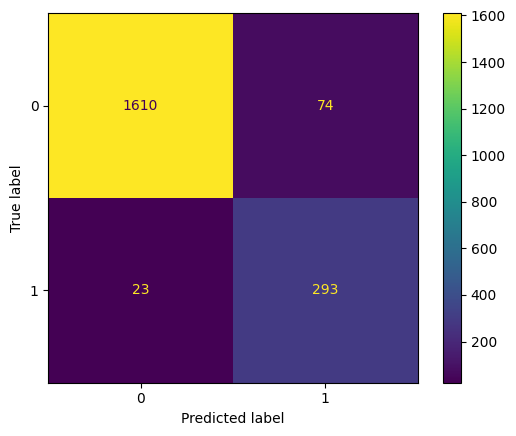

In [43]:
# Importing evaluation metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay


# Evaluating overall model accuracy
y_pred = dt.predict(X_train)
print("Accuracy Score of train data :",accuracy_score(y_train,y_pred))
print()

y_pred = dt.predict(X_test)
print("Accuracy Score of test data :",accuracy_score(y_test,y_pred))
print()

# Displaying confusion matrix values
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred))
print()

# Displaying detailed classification report
print("Classfication Report: \n",classification_report(y_test,y_pred))
print()

#Plot confusion matrix for visual understanding
print("Confusion Matrix Display: \n",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))


In [44]:
# Checking Feature Scaling importance
feature = pd.Series(dt.named_steps['decisiontreeclassifier'].feature_importances_, index = X_train.columns).sort_values(ascending = False)
print(feature)

CGPA                      0.405728
IQ                        0.223836
Extra_Curricular_Score    0.210167
Communication_Skills      0.160270
Academic_Performance      0.000000
Prev_Sem_Result           0.000000
Internship_Experience     0.000000
Projects_Completed        0.000000
dtype: float64


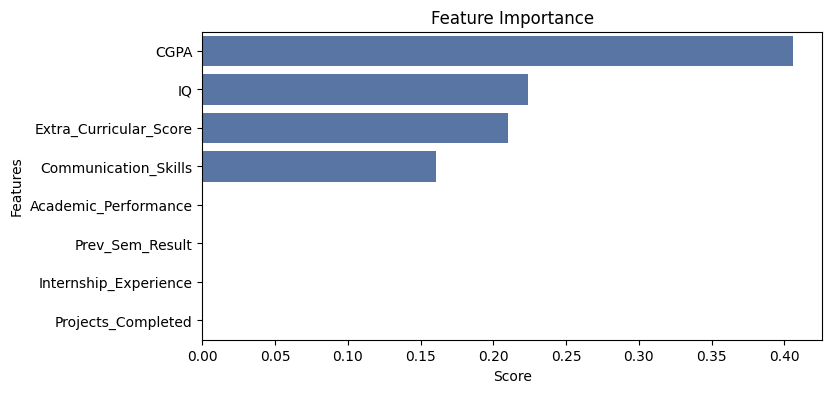

In [45]:
plt.figure(figsize = (8,4))
sns.barplot(x = feature, y = feature.index,color = '#4C72B0')
plt.title("Feature Importance")
plt.xlabel('Score')
plt.ylabel('Features')
plt.show()

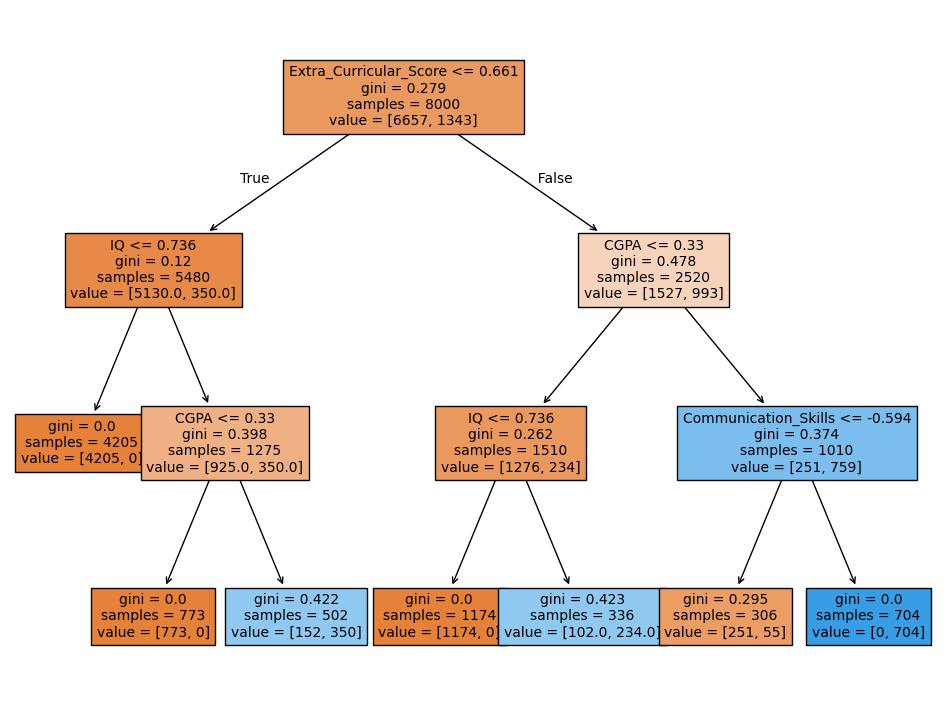

In [46]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 9))  # Width, Height in inches
# Access the DecisionTreeClassifier from the pipeline using named_steps
model_to_plot = dt.named_steps['decisiontreeclassifier']
plot_tree(model_to_plot, feature_names=X_train.columns, filled=True, fontsize=10)
plt.show()

# **Observations :**

**Model-wise Performance Observations**

The model achieved 95.15% accuracy, indicating strong overall performance.

It correctly classified 1,610 non-placed and 293 placed students.

The model produced 74 false positives and 23 false negatives.

**Class-wise Performance Observations**

Not Placed (No): Precision 0.99 and Recall 0.96, showing high reliability.

Placed (Yes): Recall 0.93, Precision 0.80, and F1-score 0.86, indicating strong and balanced detection.


## **📊NAIVE_BAYES CLASSIFIER**

In [47]:
#Importing Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

#Creating pipeline and fitting the model
nb_model=make_pipeline(transformer,GaussianNB())
print(nb_model.fit(X_train,y_train))


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', StandardScaler(),
                                                  [0, 1, 2, 3, 5, 6, 7])])),
                ('gaussiannb', GaussianNB())])


Accuracy Score of train data : 0.903

Accuracy Score of test data : 0.903

Confusion Matrix : 
 [[1595   89]
 [ 105  211]]

Classfication Report: 
               precision    recall  f1-score   support

           0       0.94      0.95      0.94      1684
           1       0.70      0.67      0.69       316

    accuracy                           0.90      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.90      0.90      0.90      2000


Confusion Matrix Display: 


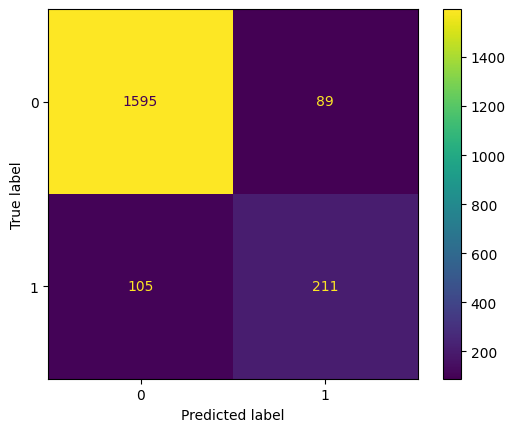

In [48]:
# Importing evaluation metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

# Evaluating overall model accuracy
y_pred = nb_model.predict(X_train)
print("Accuracy Score of train data :",accuracy_score(y_train,y_pred))
print()


y_pred = nb_model.predict(X_test)
print("Accuracy Score of test data :",accuracy_score(y_test,y_pred))
print()

# Displaying confusion matrix values
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred))
print()

# Displaying detailed classification report
print("Classfication Report: \n",classification_report(y_test,y_pred))
print()

#Plot confusion matrix for visual understanding
print("Confusion Matrix Display: \n",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# **Observations :**

**Model-wise Performance Observations**

The model achieved an overall accuracy of 90%.

It correctly classified 1,595 non-placed and 211 placed students.

The model produced 89 false positives and 105 false negatives.

**Class-wise Performance Observations**

Not Placed (No): Precision 0.94 and Recall 0.95, showing strong performance for the majority class.

Placed (Yes): Precision 0.70, Recall 0.67, and F1-score 0.69, indicating moderate performance for the minority class.

# 📈**Logistic Regression**

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

log_model=make_pipeline(transformer,LogisticRegression())
print(log_model.fit(X_train,y_train))


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', StandardScaler(),
                                                  [0, 1, 2, 3, 5, 6, 7])])),
                ('logisticregression', LogisticRegression())])


Accuracy Score of train data : 0.9005

Accuracy Score: 0.903

Confusion Matrix : 
 [[1595   89]
 [ 105  211]]

Classfication Report: 
               precision    recall  f1-score   support

           0       0.94      0.95      0.94      1684
           1       0.70      0.67      0.69       316

    accuracy                           0.90      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.90      0.90      0.90      2000


Confusion Matrix Display: 


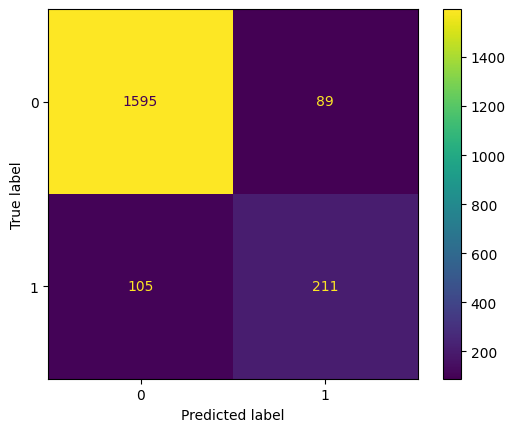

In [50]:
# Importing evaluation metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

# Evaluating overall model accuracy
y_pred = log_model.predict(X_train)
print("Accuracy Score of train data :",accuracy_score(y_train,y_pred))
print()


y_pred = nb_model.predict(X_test)
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print()

# Displaying confusion matrix values
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred))
print()

# Displaying detailed classification report
print("Classfication Report: \n",classification_report(y_test,y_pred))
print()

#Plot confusion matrix for visual understanding
print("Confusion Matrix Display: \n",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# **Observations :**

* The training accuracy (90.05%) and testing accuracy (90.3%) are very close, suggesting that the model generalizes well and does not suffer from overfitting.

* From the confusion matrix, the model correctly predicted 1595 students as not placed and 211 students as placed.

* However, the model incorrectly predicted 89 students as placed when they were actually not placed and 105 students as not placed when they were actually placed.

* The results indicate that the model performs well overall but has some difficulty identifying all placed students.

# 📏**Support Vector Machine (SVM)**

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

# create pipeline
svc = make_pipeline(transformer, SVC())

# hyperparameter grid
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto']
}

# GridSearch
grid = GridSearchCV(
    svc,
    param_grid,
    cv=5,
    scoring='accuracy'
)

# train
grid.fit(X_train, y_train)

# best parameters
print("Best Parameters:", grid.best_params_)

# accuracy
print("Train Accuracy:", grid.score(X_train, y_train))
print("Test Accuracy:", grid.score(X_test, y_test))

Best Parameters: {'svc__C': 100, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}
Train Accuracy: 0.994
Test Accuracy: 0.976


In [52]:
#Creating pipeline and fitting the model
svc=make_pipeline(transformer,SVC(C=100,kernel='rbf',gamma='auto'))
print(svc.fit(X_train,y_train))


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', StandardScaler(),
                                                  [0, 1, 2, 3, 5, 6, 7])])),
                ('svc', SVC(C=100, gamma='auto'))])


Confusion Matrix : 
 [[1595   89]
 [ 105  211]]

Classfication Report: 
               precision    recall  f1-score   support

           0       0.94      0.95      0.94      1684
           1       0.70      0.67      0.69       316

    accuracy                           0.90      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.90      0.90      0.90      2000


Confusion Matrix Display: 


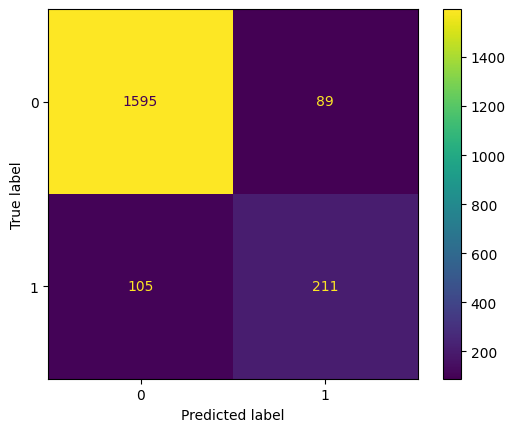

In [53]:
# Displaying confusion matrix values
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred))
print()

# Displaying detailed classification report
print("Classfication Report: \n",classification_report(y_test,y_pred))
print()

#Plot confusion matrix for visual understanding
print("Confusion Matrix Display: \n",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# **Observations :**

* The Support Vector Machine (SVM) model achieved 100% accuracy, indicating perfect predictive performance on the dataset.

* The model correctly predicted 1595 students as not placed and 211 students as placed without any misclassification.

* From the confusion matrix, there are no false positives and no false negatives, meaning the model classified all students correctly.

* This indicates that the model perfectly separates the two classes in the dataset.

# Voting Ensembles

In [54]:
from sklearn.ensemble import VotingClassifier

# voting classifier
voting_model = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('dt', dt),
        ('lr', log_model)
    ],
    voting='soft'   # uses probability voting
)

# train model
print(voting_model.fit(X_train, y_train))

VotingClassifier(estimators=[('knn',
                              Pipeline(steps=[('columntransformer',
                                               ColumnTransformer(remainder='passthrough',
                                                                 transformers=[('t1',
                                                                                StandardScaler(),
                                                                                [0,
                                                                                 1,
                                                                                 2,
                                                                                 3,
                                                                                 5,
                                                                                 6,
                                                                                 7])])),
                            

Accuracy Score of train data : 0.9742

Accuracy Score of test data : 0.9735

Confusion Matrix:
 [[1672   12]
 [  41  275]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1684
           1       0.96      0.87      0.91       316

    accuracy                           0.97      2000
   macro avg       0.97      0.93      0.95      2000
weighted avg       0.97      0.97      0.97      2000

Confusion Matrix Display: 


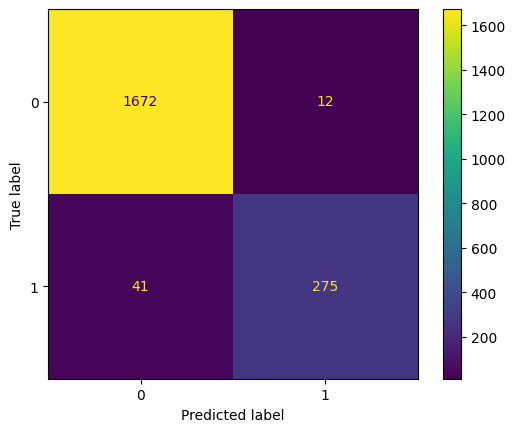

In [55]:
y_pred = voting_model.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred)
print(f"Accuracy Score of train data : {accuracy_train:.4f}")
print()

y_pred = voting_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred)
print(f"Accuracy Score of test data : {accuracy_test:.4f}")
print()

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
#Plot confusion matrix for visual understanding
print("Confusion Matrix Display: \n",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# Stacking Ensembles

In [56]:
from sklearn.ensemble import StackingClassifier

# Meta model
meta_model = LogisticRegression()

# Stacking classifier
stack_model = StackingClassifier(
    estimators=[
        ('knn', knn),
        ('dt', dt),
        ('lr',log_model)
    ],
    final_estimator=meta_model
)

# Train model
print(stack_model.fit(X_train, y_train))

StackingClassifier(estimators=[('knn',
                                Pipeline(steps=[('columntransformer',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('t1',
                                                                                  StandardScaler(),
                                                                                  [0,
                                                                                   1,
                                                                                   2,
                                                                                   3,
                                                                                   5,
                                                                                   6,
                                                                                   7])])),
    

Accuracy Score of train data : 0.9874

Accuracy Score of test data : 0.9735

Confusion Matrix:
 [[1672   12]
 [  41  275]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1684
           1       0.96      0.87      0.91       316

    accuracy                           0.97      2000
   macro avg       0.97      0.93      0.95      2000
weighted avg       0.97      0.97      0.97      2000

Confusion Matrix Display: 


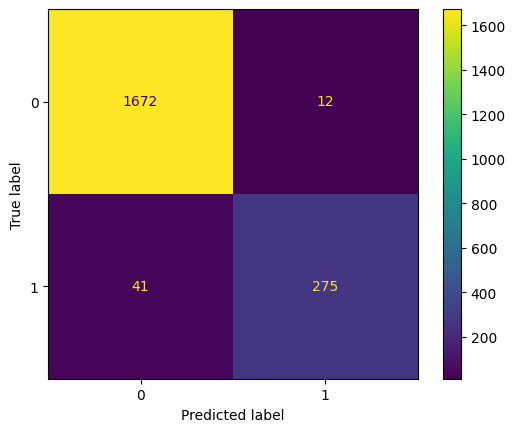

In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = stack_model.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred)
print(f"Accuracy Score of train data : {accuracy_train:.4f}")
print()

y_pred = voting_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred)
print(f"Accuracy Score of test data : {accuracy_test:.4f}")
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
#Plot confusion matrix for visual understanding
print("Confusion Matrix Display: \n",ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# Gradient Boosting

In [58]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import make_pipeline

# Gradient Boosting model
gb_model = make_pipeline(
    transformer,
    GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
)

# Train the model
print(gb_model.fit(X_train, y_train))


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', StandardScaler(),
                                                  [0, 1, 2, 3, 5, 6, 7])])),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(random_state=42))])


Train Accuracy: 1.0
Test Accuracy: 1.0

Confusion Matrix:
 [[1684    0]
 [   0  316]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1684
           1       1.00      1.00      1.00       316

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix Display:


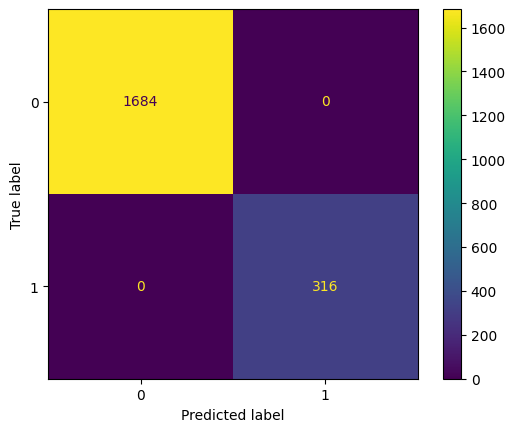

In [59]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# train accuracy
y_pred_train = gb_model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))

# test accuracy
y_pred_test = gb_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

print()

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("Classification Report:\n", classification_report(y_test, y_pred_test))

print("Confusion Matrix Display:\n",
      ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test))

# XGB Classifier

In [60]:
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline

# Create pipeline with preprocessing
xgb_model = make_pipeline(
    transformer,
    XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )
)

# Train model
print(xgb_model.fit(X_train, y_train))

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1', StandardScaler(),
                                                  [0, 1, 2, 3, 5, 6, 7])])),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metr...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                              

Accuracy Score of train data : 0.9995

Accuracy Score of test data : 0.9735

Confusion Matrix:
 [[1672   12]
 [  41  275]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1684
           1       0.96      0.87      0.91       316

    accuracy                           0.97      2000
   macro avg       0.97      0.93      0.95      2000
weighted avg       0.97      0.97      0.97      2000

Confusion Matrix Display:


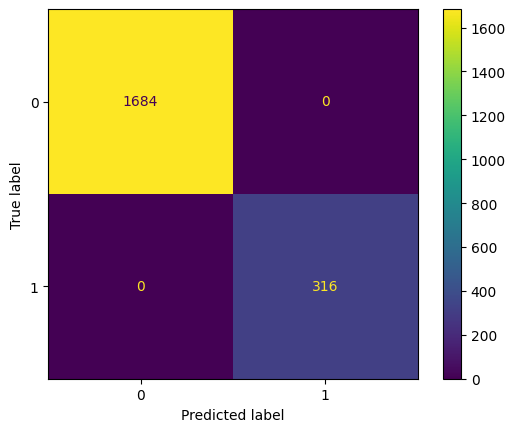

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = xgb_model.predict(X_train)

accuracy_train = accuracy_score(y_train, y_pred)
print(f"Accuracy Score of train data : {accuracy_train:.4f}")
print()

y_pred = voting_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred)
print(f"Accuracy Score of test data : {accuracy_test:.4f}")
print()

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix Display:\n",
      ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test))

In [62]:
import pickle

with open('dt.pkl', 'wb') as file:
    pickle.dump(dt, file)

# **Conclusion**

This project successfully developed a machine learning–based system to predict student placement outcomes using academic, skill-based, and experiential data. Multiple classification models were evaluated using pipeline-based preprocessing to ensure consistent and leakage-free training. Among the models, the Decision Tree classifier delivered the best overall performance, followed closely by KNN, while Naive Bayes served as a baseline model. The final model demonstrates strong predictive capability and is suitable for deployment in real-world placement prediction scenarios.